In [1]:
from shapely.geometry import Point, Polygon, MultiPolygon, LineString
import folium
import geopandas as gpd
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

In [2]:
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir/'src'))
from map2grid import plot_with_google_satellite

In [3]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
trafo_gdf = gpd.read_file('../outputs/table_transformers_remove_disconnected.gpkg')

basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

In [4]:
output_dir = "../figures"

In [5]:
# Update total electricity demand in second dataframe based on BusID and NodeID
def update_electricity_demand(df1, df2, variable):
    # Ensure BusID is unique, resolve conflicts by summing or taking the mean
    mapping = df1.groupby('BusID')[variable].sum()
    # Map to df2 based on Index
    df2[variable] = df2['NodeID'].map(mapping)
    return df2

In [6]:
gens_gdf['energy_source'].unique()

array(['Hydro', 'Wind', 'Gas', 'Solar', 'Coal', 'Other Fossil',
       'Bioenergy'], dtype=object)

In [7]:
def plot_power_grid_map(loads_gdf, gens_gdf, nodes_gdf, lines_gdf, output_dir, basemap):
    # --- Step 1: Update demand and generation to nodes_gdf ---
    nodes_gdf = update_electricity_demand(loads_gdf, nodes_gdf, 'total_electricity_demand')
    nodes_gdf = update_electricity_demand(gens_gdf, nodes_gdf, 'electricity_generation_GWh')

    # --- Step 2: Normalize to 0-1 range ---
    nodes_gdf['normalized_electricity_generation_GWh'] = (
        (nodes_gdf['electricity_generation_GWh'] - nodes_gdf['electricity_generation_GWh'].min()) /
        (nodes_gdf['electricity_generation_GWh'].max() - nodes_gdf['electricity_generation_GWh'].min())
    )
    nodes_gdf['normalized_total_electricity_demand'] = (
        (nodes_gdf['total_electricity_demand'] - nodes_gdf['total_electricity_demand'].min()) /
        (nodes_gdf['total_electricity_demand'].max() - nodes_gdf['total_electricity_demand'].min())
    )

    print('Total electricity production: ', nodes_gdf['electricity_generation_GWh'].sum())
    print('Total electricity demand: ', nodes_gdf['total_electricity_demand'].sum())

    # --- Step 3: Reproject to WGS84 ---
    nodes_gdf_plot = nodes_gdf.to_crs(epsg=4326)
    lines_gdf_plot = lines_gdf.to_crs(epsg=4326)
    basemap = basemap.to_crs(epsg=4326)

    # --- Step 5: Create figure ---
    fig, ax = plt.subplots(figsize=(6, 10))

    # --- Step 6: Plot nodes ---
    for idx, row in nodes_gdf_plot.iterrows():
        if pd.notna(row['electricity_generation_GWh']):
            ax.plot(row.geometry.x, row.geometry.y, 'bo',
                    markersize=row['normalized_electricity_generation_GWh'] * 50, alpha=0.3, markeredgewidth=0)
        elif pd.notna(row['total_electricity_demand']):
            ax.plot(row.geometry.x, row.geometry.y, 'go',
                    markersize=row['normalized_total_electricity_demand'] * 50, alpha=0.3, markeredgewidth=0)

    # --- Step 7: Plot transmission lines ---
    for idx, row in lines_gdf_plot.iterrows():
        if row['voltage'] == 500.0:
            color = '#B54EB2'; zorder = 3
        elif row['voltage'] == 220.0:
            color = '#C73030'; zorder = 2
        elif row['voltage'] == 110.0:
            color = '#B7A115'; zorder = 1
        else:
            color = 'black'; zorder = 0
        ax.plot(*row.geometry.xy, color=color, zorder=zorder, linewidth=0.6)

    # --- Step 8: Plot basemap ---
    basemap.plot(ax=ax, color='#EBEBEB', edgecolor='white', linewidth=0.3, zorder=0, rasterized=True)

    # --- Step 9: Decorate plot ---
    ax.set_title("Vietnamese Power Grid", fontsize=9)
    ax.set_xlabel("Longitude [°]", fontsize=9)
    ax.set_ylabel("Latitude [°]", fontsize=9)
    ax.set_xlim(102, 110)
    ax.set_ylim(8, 24)
    ax.tick_params(axis='both', which='major', labelsize=8)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=5, alpha=0.6, label='Cluster of generators'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=5, alpha=0.6, label='Cluster of loads'),
        Line2D([0], [0], color='#B54EB2', lw=1, label='500kV Line'),
        Line2D([0], [0], color='#C73030', lw=1, label='220kV Line'),
        Line2D([0], [0], color='#B7A115', lw=1, label='110kV Line')
        # Line2D([0], [0], color='#8F7EE5', lw=1, label='500kV Line'),
        # Line2D([0], [0], color='#B22C2B', lw=1, label='220kV Line'),
        # Line2D([0], [0], color='#B26F2C', lw=1, label='110kV Line')
    ]
    ax.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.05, 0.25), fontsize=9)

    # --- Step 10: Save output ---
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "Fig3_vietnamese_power_grid.png"), dpi=800, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, "Fig3_vietnamese_power_grid.svg"), dpi=600, bbox_inches='tight')

    plt.show()

Total electricity production:  276440.00000000006
Total electricity demand:  116589.09085071347


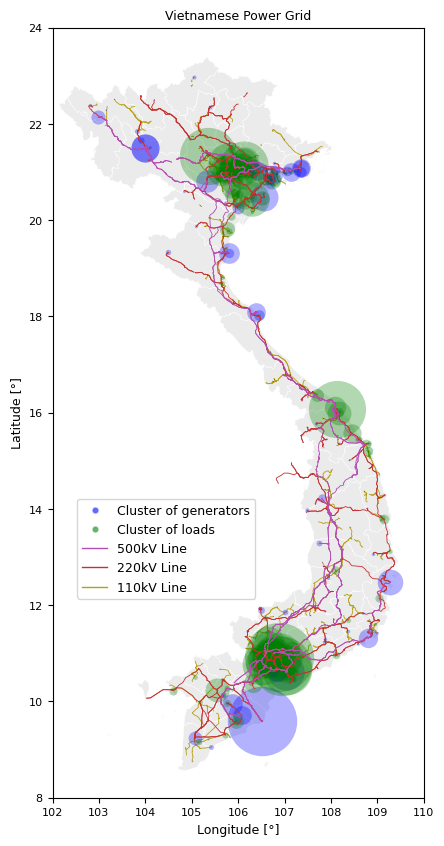

In [8]:
plot_power_grid_map(
    loads_gdf, gens_gdf, nodes_gdf, lines_gdf,
    output_dir=output_dir, basemap=basemap)

In [ ]:
subs = gpd.read_file("../data/osm/substation.gpkg", driver='GPKG')
subs = subs.to_crs(epsg=4326)
gens_gdf = gens_gdf.to_crs(epsg=4326)
lines_gdf = lines_gdf.to_crs(epsg=4326)

data_busbars = pd.read_excel('../outputs/data_busbars.xlsx')
data_busbars_gdf = gpd.GeoDataFrame(data_busbars, geometry=gpd.GeoSeries.from_wkt(data_busbars['geometry']))

data_singular_ways = pd.read_excel('../outputs/data_singular_ways.xlsx')
data_singular_ways_gdf = gpd.GeoDataFrame(data_singular_ways, geometry=gpd.GeoSeries.from_wkt(data_singular_ways['geometry']))


m = plot_with_google_satellite(
    data=lines_gdf,
    data_busbars= data_busbars_gdf,
    data_singular_ways=data_singular_ways_gdf,
    xlim=(107.631, 107.640), ylim=(11.964, 11.9722),
    subs_gdf=subs,
    gens_gdf=gens_gdf
    )
m.save('../figures/map_with_nodes.html')

c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [42]:
type(nodes_gdf['OriginalID'].loc[0])

numpy.float64

In [47]:
print("The number of all buses:", len(nodes_gdf))

count_sub = nodes_gdf['OriginalID'].apply(lambda x: len(str(int(x))) > 6).sum()
print("The number of substations:", count_sub)

count_vir = nodes_gdf['OriginalID'].apply(lambda x: len(str(int(x))) < 6).sum()
print("The number of virtual buses: ", count_vir)

The number of all buses: 3692
The number of substations: 818
The number of virtual buses:  2874


In [48]:
print("The number of all lines:", len(lines_gdf))

The number of all lines: 6799


In [52]:
print("The total length of lines:", sum(lines_gdf['Length']))

The total length of lines: 46689.93488821478


In [ ]:
print("The number of transformers:", len(trafo_gdf))

The number of transformers: 235


In [11]:
import folium
import geopandas as gpd
from shapely.geometry import LineString, Point, Polygon, MultiPolygon

def plot_with_google_satellite_and_gpkg(gpkg_path, output_html_path, xlim, ylim):
    # Step 1: 地图中心点
    center_lat = (ylim[0] + ylim[1]) / 2
    center_lon = (xlim[0] + xlim[1]) / 2

    # Step 2: 创建 Folium 地图，使用 Google Satellite 底图
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)
    
    # 添加 Google Satellite 图层
    folium.TileLayer(
        tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
        attr="Google Satellite",
        name="Google Satellite",
        overlay=True,
        control=True
    ).add_to(m)
    
    # Step 3: 读取 GPKG 文件并加载图层
    gdf_nodes = gpd.read_file(gpkg_path, layer='nodes').to_crs(epsg=4326)
    gdf_lines = gpd.read_file(gpkg_path, layer='lines').to_crs(epsg=4326)
    gdf_loads = gpd.read_file(gpkg_path, layer='loads').to_crs(epsg=4326)

    # Step 4: 绘制不同的元素，根据 disconnected flag 设置颜色，并添加 Popup
    def plot_geometry(gdf, layer_name):
        # 先绘制 disconnected == 'no' 的元素
        for _, row in gdf[gdf['disconnected'] == 'no'].iterrows():
            geom = row.geometry
            color = '#a4ec7e'  # disconnected == 'no' 颜色

            # 根据图层类型生成对应的 Popup 内容
            if layer_name == 'nodes':
                popup_content = f"NodeID: {row['NodeID']}<br>OriginalID: {row['OriginalID']}"
            elif layer_name == 'lines':
                popup_content = f"LineID: {row['LineID']}<br>fromNode: {row['fromNode']}<br>toNode: {row['toNode']}<br>osm_id: {row['osm_id']}"
            elif layer_name == 'loads':
                popup_content = f"osm_id: {row['osmid']}<br>BusID: {row['BusID']}"

            popup = folium.Popup(popup_content, max_width=300)

            # 绘制 LineString
            if isinstance(geom, LineString):
                coords = [(lat, lon) for lon, lat in geom.coords]
                folium.PolyLine(coords, color=color, weight=2, opacity=0.7, popup=popup).add_to(m)
            # 绘制 Point
            elif isinstance(geom, Point):
                folium.CircleMarker(
                    location=[geom.y, geom.x],
                    radius=5,
                    color=color,
                    fill=True,
                    fill_opacity=0.7,
                    popup=popup
                ).add_to(m)
            # 绘制 Polygon
            elif isinstance(geom, Polygon):
                coords = list(geom.exterior.coords)
                folium.Polygon(
                    locations=coords,
                    color=color,
                    weight=2,
                    opacity=0.7,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.3,
                    popup=popup
                ).add_to(m)
            # 绘制 MultiPolygon
            elif isinstance(geom, MultiPolygon):
                for poly in geom.geoms:
                    coords = list(poly.exterior.coords)
                    folium.Polygon(
                        locations=coords,
                        color=color,
                        weight=2,
                        opacity=0.7,
                        fill=True,
                        fill_color=color,
                        fill_opacity=0.3,
                        popup=popup
                    ).add_to(m)

        # 然后绘制 disconnected == 'yes' 的元素
        for _, row in gdf[gdf['disconnected'] == 'yes'].iterrows():
            geom = row.geometry
            color = '#ca235d'  # disconnected == 'yes' 颜色

            # 根据图层类型生成对应的 Popup 内容
            if layer_name == 'nodes':
                popup_content = f"NodeID: {row['NodeID']}<br>OriginalID: {row['OriginalID']}"
            elif layer_name == 'lines':
                popup_content = f"LineID: {row['LineID']}<br>fromNode: {row['fromNode']}<br>toNode: {row['toNode']}<br>osm_id: {row['osm_id']}"
            elif layer_name == 'loads':
                popup_content = f"osm_id: {row['osmid']}<br>BusID: {row['BusID']}"

            popup = folium.Popup(popup_content, max_width=300)

            # 绘制 LineString
            if isinstance(geom, LineString):
                coords = [(lat, lon) for lon, lat in geom.coords]
                folium.PolyLine(coords, color=color, weight=2, opacity=0.7, popup=popup).add_to(m)
            # 绘制 Point
            elif isinstance(geom, Point):
                folium.CircleMarker(
                    location=[geom.y, geom.x],
                    radius=5,
                    color=color,
                    fill=True,
                    fill_opacity=0.7,
                    popup=popup
                ).add_to(m)
            # 绘制 Polygon
            elif isinstance(geom, Polygon):
                coords = list(geom.exterior.coords)
                folium.Polygon(
                    locations=coords,
                    color=color,
                    weight=2,
                    opacity=0.7,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.3,
                    popup=popup
                ).add_to(m)
            # 绘制 MultiPolygon
            elif isinstance(geom, MultiPolygon):
                for poly in geom.geoms:
                    coords = list(poly.exterior.coords)
                    folium.Polygon(
                        locations=coords,
                        color=color,
                        weight=2,
                        opacity=0.7,
                        fill=True,
                        fill_color=color,
                        fill_opacity=0.3,
                        popup=popup
                    ).add_to(m)

    # 绘制每个图层的元素
    plot_geometry(gdf_nodes, 'nodes')
    plot_geometry(gdf_lines, 'lines')
    plot_geometry(gdf_loads, 'loads')

    # 添加 Substations
    subs_gdf = gpd.read_file("../data/osm/substation.gpkg", driver='GPKG')
    if subs_gdf is not None:
        subs_gdf = subs_gdf.to_crs(epsg=4326)
        for idx, row in subs_gdf.iterrows():
            geometry = row.geometry
            tooltip = row.get("name", "Substation")
            
            if isinstance(geometry, Point):  # 如果是 Point 类型
                lon, lat = geometry.x, geometry.y
                folium.Marker(
                    location=[lat, lon],
                    popup=f"Sub: {tooltip}",
                    icon=folium.Icon(color='grey', icon='info-sign')
                ).add_to(m)

            elif isinstance(geometry, LineString):
                coords = [(lat, lon) for lon, lat in geometry.coords]
                folium.PolyLine(
                    coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, weight=2, opacity=0.7, tooltip=tooltip
                ).add_to(m)

            elif isinstance(geometry, Polygon):  # 如果是 Polygon 类型
                coords = list(geometry.exterior.coords)
                folium.Polygon(locations=coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, tooltip=tooltip).add_to(m)
                
            elif isinstance(geometry, MultiPolygon):  # 如果是 MultiPolygon 类型
                for poly in geometry.geoms:
                    coords = list(poly.exterior.coords)
                    folium.Polygon(locations=coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, tooltip=tooltip).add_to(m)

    # Step 6: 保存地图为 HTML 文件
    m.save(output_html_path)
    print(f"地图已保存为 {output_html_path}")

# 例子：使用 .gpkg 文件路径并保存为 .html
gpkg_path = "../outputs/disconnected_elements_flagged.gpkg"  # 你的 GPKG 文件路径
output_html_path = "../outputs/disconnected_elements_map.html"  # 输出 HTML 文件路径

plot_with_google_satellite_and_gpkg(gpkg_path, output_html_path,
                                    xlim=(107.631, 107.640), ylim=(11.964, 11.9722))


c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
C:\Users\mye500\AppData\Local\Temp\ipykernel_3368\2756773077.py:161: UserWarning: color argument of Icon should be one of: {'darkpurple', 'white', 'lightgray', 'darkgreen', 'darkblue', 'blue', 'purple', 'lightblue', 'orange', 'beige', 'red', 'lightgreen', 'gray', 'black', 'darkred', 'lightred', 'pink', 'cadetblue', 'green'}.
  icon=folium.Icon(color='grey', icon='info-sign')


地图已保存为 ../outputs/disconnected_elements_map.html


In [8]:
def plot_with_google_satellite_and_gpkg(gpkg_path, output_html_path, xlim, ylim):
    # Step 1: 地图中心点
    center_lat = (ylim[0] + ylim[1]) / 2
    center_lon = (xlim[0] + xlim[1]) / 2

    # Step 2: 创建 Folium 地图，使用 Google Satellite 底图
    m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles=None)
    
    # 添加 Google Satellite 图层
    folium.TileLayer(
        tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
        attr="Google Satellite",
        name="Google Satellite",
        overlay=True,
        control=True
    ).add_to(m)

    # Step 3: 添加 Substations
    subs_gdf = gpd.read_file("../data/osm/substation.gpkg", driver='GPKG')
    if subs_gdf is not None:
        subs_gdf = subs_gdf.to_crs(epsg=4326)
        for idx, row in subs_gdf.iterrows():
            geometry = row.geometry
            tooltip = row.get("name", "Substation")
            
            if isinstance(geometry, Point):  # 如果是 Point 类型
                lon, lat = geometry.x, geometry.y
                folium.Marker(
                    location=[lat, lon],
                    popup=f"Sub: {tooltip}",
                    icon=folium.Icon(color='grey', icon='info-sign')
                ).add_to(m)

            elif isinstance(geometry, LineString):
                coords = [(lat, lon) for lon, lat in geometry.coords]
                folium.PolyLine(
                    coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, weight=2, opacity=0.7, tooltip=tooltip
                ).add_to(m)

            elif isinstance(geometry, Polygon):  # 如果是 Polygon 类型
                coords = list(geometry.exterior.coords)
                folium.Polygon(locations=coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, tooltip=tooltip).add_to(m)
                
            elif isinstance(geometry, MultiPolygon):  # 如果是 MultiPolygon 类型
                for poly in geometry.geoms:
                    coords = list(poly.exterior.coords)
                    folium.Polygon(locations=coords, color='black', fill=True, fill_color='grey', fill_opacity=0.5, tooltip=tooltip).add_to(m)

    # Step 4: 读取 GPKG 中所有图层
    gdf_nodes = gpd.read_file(gpkg_path, layer='nodes').to_crs(epsg=4326)
    gdf_lines = gpd.read_file(gpkg_path, layer='lines').to_crs(epsg=4326)
    gdf_loads = gpd.read_file(gpkg_path, layer='loads').to_crs(epsg=4326)

    # Step 5: 绘制顺序：先绘制 disconnected == 'no'，再绘制 'yes'
    for disc in ['no', 'yes']:
        # --- 绘制 lines ---
        sub_lines = gdf_lines[gdf_lines['disconnected'] == disc]
        for _, row in sub_lines.iterrows():
            geom = row.geometry
            if isinstance(geom, LineString):
                coords = [(lat, lon) for lon, lat in geom.coords]
                color = '#ca235d' if disc == 'yes' else '#a4ec7e'
                popup_html = (
                    f"LineID: {row.get('LineID')}<br>"
                    f"fromNode: {row.get('fromNode')}<br>"
                    f"toNode: {row.get('toNode')}<br>"
                    f"osm_id: {row.get('osm_id')}"
                )
                folium.PolyLine(
                    coords,
                    color=color,
                    weight=2,
                    opacity=0.7,
                    popup=folium.Popup(popup_html, max_width=300)
                ).add_to(m)

        # --- 绘制 nodes ---
        sub_nodes = gdf_nodes[gdf_nodes['disconnected'] == disc]
        for _, row in sub_nodes.iterrows():
            geom = row.geometry
            if isinstance(geom, Point):
                color = '#ca235d' if disc == 'yes' else '#a4ec7e'
                popup_html = (
                    f"NodeID: {row.get('NodeID')}<br>"
                    f"OriginalID: {row.get('OriginalID')}"
                )
                folium.CircleMarker(
                    location=[geom.y, geom.x],
                    radius=5,
                    color=color,
                    fill=True,
                    fill_opacity=0.7,
                    popup=folium.Popup(popup_html, max_width=300)
                ).add_to(m)

        # --- 绘制 loads（polygon/multipolygon）---
        sub_loads = gdf_loads[gdf_loads['disconnected'] == disc]
        for _, row in sub_loads.iterrows():
            color = '#ca235d' if disc == 'yes' else '#a4ec7e'
            popup_html = (
                f"osm_id: {row.get('osmid')}<br>"
                f"BusID: {row.get('BusID')}"
            )
            if isinstance(row.geometry, Polygon):
                geom_list = [row.geometry]
            elif isinstance(row.geometry, MultiPolygon):
                geom_list = row.geometry.geoms
            else:
                continue  # skip if not polygonal

            for poly in geom_list:
                coords = [(lat, lon) for lon, lat in poly.exterior.coords]
                folium.Polygon(
                    locations=coords,
                    color=color,
                    weight=2,
                    opacity=0.7,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.3,
                    popup=folium.Popup(popup_html, max_width=300)
                ).add_to(m)
    
    # Step 6: 保存地图为 HTML 文件
    m.save(output_html_path)

In [15]:
gpkg_path = "../outputs/disconnected_elements_flagged.gpkg"
output_html_path = "../outputs/disconnected_elements_map.html"

plot_with_google_satellite_and_gpkg(
    gpkg_path,
    output_html_path,
    xlim=(107.631, 107.640),
    ylim=(11.964, 11.9722)
)

c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
C:\Users\mye500\AppData\Local\Temp\ipykernel_3368\463384177.py:31: UserWarning: color argument of Icon should be one of: {'darkpurple', 'white', 'lightgray', 'darkgreen', 'darkblue', 'blue', 'purple', 'lightblue', 'orange', 'beige', 'red', 'lightgreen', 'gray', 'black', 'darkred', 'lightred', 'pink', 'cadetblue', 'green'}.
  icon=folium.Icon(color='grey', icon='info-sign')


# Fragility curves

In [3]:
module_path = "../src"
sys.path.append(os.path.abspath(module_path))
from percolation_analysis_tc import load_curves

In [4]:
curve_path = '../data/fragility_curves.xlsx'
curves = load_curves(curve_path, sheet_name='test')

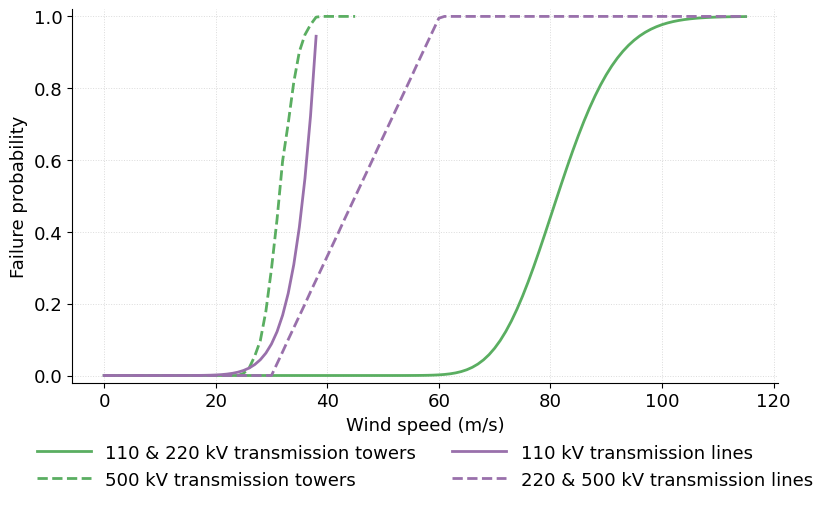

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

fig, ax = plt.subplots(figsize=(8.6, 5.2))

label_mapping = {
    "W3.15": "110 & 220 kV transmission towers",
    "W3.45": "500 kV transmission towers",
    "W6.1": "110 kV transmission lines",
    "W6.2": "220 & 500 kV transmission lines"
}

# Same color per asset type, different linestyles per voltage
style_mapping = {
    "W3.15": {"color": "#5AAE61", "ls": "-"},   # towers, lower voltage
    "W3.45": {"color": "#5AAE61", "ls": "--"},  # towers, higher voltage
    "W6.1":  {"color": "#9970AB", "ls": "-"},   # lines, lower voltage
    "W6.2":  {"color": "#9970AB", "ls": "--"}   # lines, higher voltage
}

x = curves["Wind speed"]

for col, label in label_mapping.items():
    ax.plot(
        x,
        curves[col],
        label=label,
        color=style_mapping[col]["color"],
        linestyle=style_mapping[col]["ls"],
        lw=2.0
    )

# Axis labels
ax.set_xlabel("Wind speed (m/s)", fontsize=13)
ax.set_ylabel("Failure probability", fontsize=13)

# Axis limits and ticks
ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.set_major_locator(MaxNLocator(nbins=7))

# Grid and spines (publication style)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=13)

# Legend outside, clean
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),  # 图下方
    ncol=2,                       # 两列，更紧凑
    frameon=False,
    fontsize=13,
    handlelength=3
)

fig.tight_layout()

# Save outputs
fig.savefig("../figures/Fig_S6_wind_fragility_curves_.png", dpi=800, bbox_inches='tight')
fig.savefig("../figures/Fig_S6_wind_fragility_curves_.svg", bbox_inches='tight')

plt.show()